In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
monthly = pd.read_csv(
    'Monthly_Temperature_Totals.txt',
    skiprows=5,
    sep='\s+',
    names=['year','jan','feb','mar','apr','may','jun',
           'jul','aug','sep','oct','nov','dec','annual']
)

# Remove missing value flags
monthly.replace(-99.9, np.nan, inplace=True)

# Drop incomplete years (2026)
monthly.dropna(subset=['annual'], inplace=True)

print(f"Years: {monthly.year.min()} to {monthly.year.max()}")
print(f"Rows: {len(monthly)}")
monthly.head()

Years: 1659 to 2025
Rows: 367


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_69494/3387276438.py:4: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,year,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec,annual
0,1659,3.0,4.0,6.0,7.0,11.0,13.0,16.0,16.0,13.0,10.0,5.0,2.0,8.87
1,1660,0.0,4.0,6.0,9.0,11.0,14.0,15.0,16.0,13.0,10.0,6.0,5.0,9.10
2,1661,5.0,5.0,6.0,8.0,11.0,14.0,15.0,15.0,13.0,11.0,8.0,6.0,9.78
3,1662,5.0,6.0,6.0,8.0,11.0,15.0,15.0,15.0,13.0,11.0,6.0,3.0,9.52
4,1663,1.0,1.0,5.0,7.0,10.0,14.0,15.0,15.0,13.0,10.0,7.0,5.0,8.63


In [3]:
monthly_long = monthly.melt(
    id_vars=['year'],
    value_vars=['jan','feb','mar','apr','may','jun',
                'jul','aug','sep','oct','nov','dec'],
    var_name='month_name',
    value_name='temp_c'
)

month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
             'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}

monthly_long['month'] = monthly_long['month_name'].map(month_map)
monthly_long['date'] = monthly_long.apply(
    lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1
)
monthly_long[['year','month']].assign(day=1)

monthly_long = monthly_long.sort_values('date').reset_index(drop=True)
monthly_long.dropna(subset=['temp_c'], inplace=True)

print(f"Monthly rows: {len(monthly_long)}")
print(f"Date range: {monthly_long.date.min()} to {monthly_long.date.max()}")
monthly_long.head()

Monthly rows: 4404
Date range: 1659-01 to 2025-12


,year,month_name,temp_c,month,date
0,1659,jan,3.0,1,1659-01
1,1659,feb,4.0,2,1659-02
2,1659,mar,6.0,3,1659-03
3,1659,apr,7.0,4,1659-04
4,1659,may,11.0,5,1659-05


In [6]:
daily = pd.read_csv(
    'Central_England_Temperature_Daily_Totals.txt',
    sep='\s+',
    skiprows=2,
    names=['date','temp_c']
)
daily['date'] = pd.to_datetime(daily['date'])
daily.replace(-99.9, np.nan, inplace=True)
daily.dropna(inplace=True)

print(f"Daily rows: {len(daily)}")
print(f"Date range: {daily.date.min()} to {daily.date.max()}")
daily.head()

Daily rows: 92869
Date range: 1772-01-01 00:00:00 to 2026-04-07 00:00:00


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/var/folders/w9/njhnn_m101dbn0v_2bx160m40000gn/T/ipykernel_69494/3461356271.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,date,temp_c
0,1772-01-01,3.2
1,1772-01-02,2.0
2,1772-01-03,2.7
3,1772-01-04,2.7
4,1772-01-05,1.5


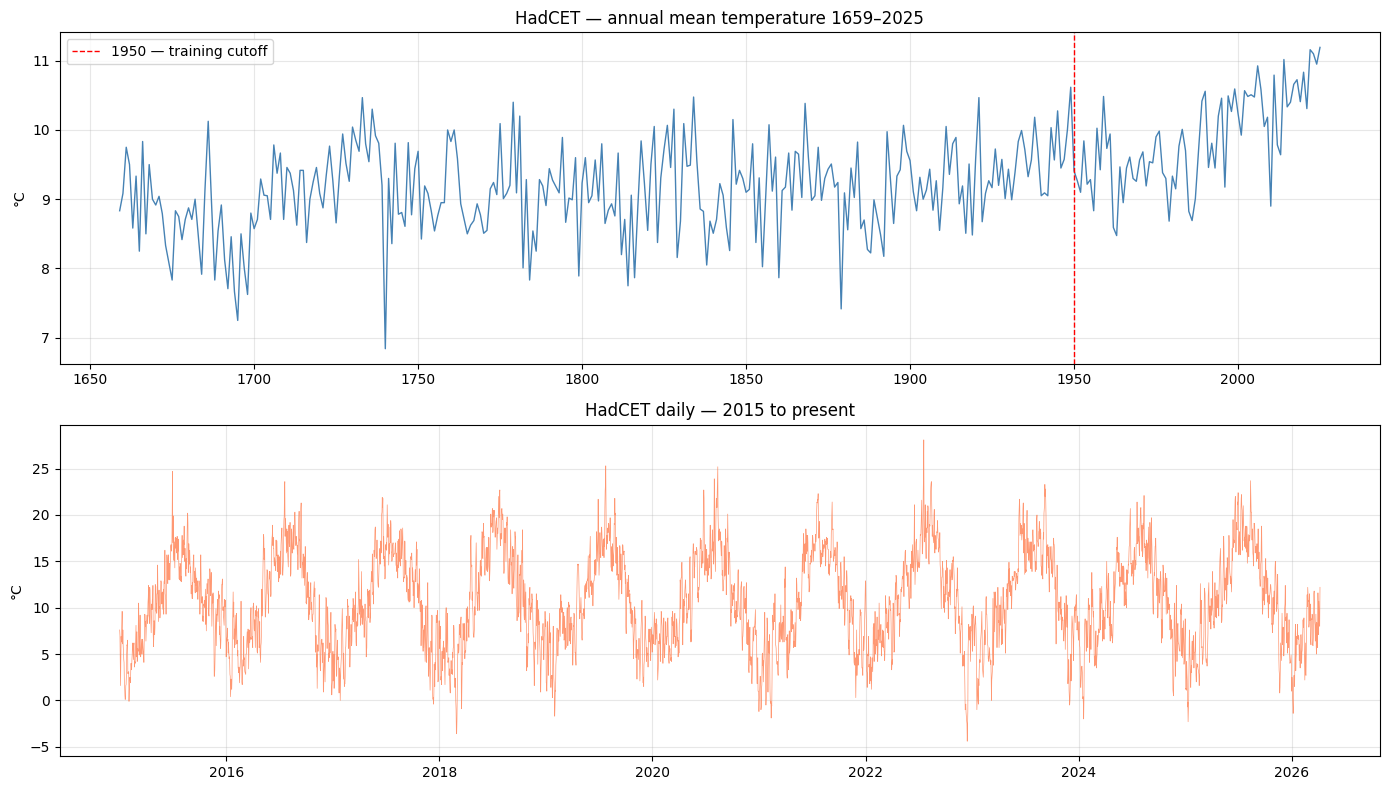

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Annual mean from monthly data
annual = monthly_long.groupby('year')['temp_c'].mean()
axes[0].plot(annual.index, annual.values, lw=1, color='steelblue')
axes[0].axvline(1950, color='red', lw=1, linestyle='--', label='1950 — training cutoff')
axes[0].set_title('HadCET — annual mean temperature 1659–2025')
axes[0].set_ylabel('°C')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily data recent decade
recent = daily[daily.date.dt.year >= 2015]
axes[1].plot(recent.date, recent.temp_c, lw=0.5, color='coral', alpha=0.8)
axes[1].set_title('HadCET daily — 2015 to present')
axes[1].set_ylabel('°C')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hadcet_overview.png', dpi=150)
plt.show()

In [8]:
nao_raw = pd.read_csv(
    'NAO_Index.csv',
    skiprows=2,
    header=None,
    usecols=range(1, 14)
)
nao_raw.columns = ['year','jan','feb','mar','apr','may','jun',
                   'jul','aug','sep','oct','nov','dec']
nao_raw.replace(-99.99, np.nan, inplace=True)

nao_long = nao_raw.melt(
    id_vars=['year'],
    value_vars=['jan','feb','mar','apr','may','jun',
                'jul','aug','sep','oct','nov','dec'],
    var_name='month_name',
    value_name='nao'
)
nao_long['month'] = nao_long['month_name'].map(month_map)
nao_long['date'] = nao_long.apply(
    lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1
)
nao_long = nao_long[['date','nao']].sort_values('date').reset_index(drop=True)

print(f"NAO rows: {len(nao_long)}")
print(f"Date range: {nao_long.date.min()} to {nao_long.date.max()}")
nao_long.head()

NAO rows: 2460
Date range: 1821-01 to 2025-12


,date,nao
0,1821-01,NaN
1,1821-02,NaN
2,1821-03,NaN
3,1821-04,NaN
4,1821-05,NaN


In [10]:
sunspot_daily = pd.read_csv(
    'Sunspot_Number_V2_0.csv',
    sep=';',
    header=None,
    usecols=[0, 1, 4],
    names=['year','month','sunspot']
)
sunspot_daily.replace(-1, np.nan, inplace=True)

sunspot_monthly = sunspot_daily.groupby(
    ['year','month']
)['sunspot'].mean().reset_index()

sunspot_monthly['date'] = sunspot_monthly.apply(
    lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1
)
sunspot_monthly = sunspot_monthly[['date','sunspot']].sort_values('date').reset_index(drop=True)

print(f"Sunspot rows: {len(sunspot_monthly)}")
print(f"Date range: {sunspot_monthly.date.min()} to {sunspot_monthly.date.max()}")
sunspot_monthly.head()

Sunspot rows: 2499
Date range: 1818-01 to 2026-03


,date,sunspot
0,1818-01,58.125000
1,1818-02,37.428571
2,1818-03,42.357143
3,1818-04,57.523810
4,1818-05,88.480000


In [12]:
aerosol_raw = pd.read_csv(
    'Global_and_Hemispheric_Mean_Aerosol_Optical_Depth_at_550_nm.csv',
    skiprows=3,
    header=None,
    usecols=[0, 1, 2],
    names=['year','dec_month','aod_global']
)

aerosol_raw['month'] = (aerosol_raw['dec_month'] * 12).round().astype(int)
aerosol_raw['month'] = aerosol_raw['month'].clip(1, 12)
aerosol_raw['year'] = aerosol_raw['year'].astype(int)

aerosol_raw['date'] = aerosol_raw.apply(
    lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1
)
aerosol = aerosol_raw[['date','aod_global']].sort_values('date').reset_index(drop=True)

print(f"Aerosol rows: {len(aerosol)}")
print(f"Date range: {aerosol.date.min()} to {aerosol.date.max()}")
aerosol.head()

Aerosol rows: 1953
Date range: 1850-01 to 2012-08


,date,aod_global
0,1850-01,0.0044
1,1850-02,0.0042
2,1850-02,0.0040
3,1850-04,0.0039
4,1850-04,0.0037


In [13]:
# Fix duplicate dates by averaging them
aerosol = aerosol.groupby('date')['aod_global'].mean().reset_index()

print(f"Aerosol rows after dedup: {len(aerosol)}")

# Master date range — 1821 to 2025
date_range = [f"{y}-{m:02d}" for y in range(1821, 2026) for m in range(1, 13)]
master = pd.DataFrame({'date': date_range})

# Merge all series
master = master.merge(monthly_long[['date','temp_c']], on='date', how='left')
master = master.merge(nao_long, on='date', how='left')
master = master.merge(sunspot_monthly, on='date', how='left')
master = master.merge(aerosol, on='date', how='left')

# Fill post-2012 aerosol with 0
master['aod_global'] = master['aod_global'].fillna(0.0)

# Add cyclical month feature
master['month'] = master['date'].str[5:7].astype(int)
master['month_sin'] = np.sin(2 * np.pi * master['month'] / 12)
master['month_cos'] = np.cos(2 * np.pi * master['month'] / 12)

print(f"Master shape: {master.shape}")
print(f"\nMissing values per column:")
print(master.isnull().sum())
master.head()

Aerosol rows after dedup: 1302
Master shape: (2460, 8)

Missing values per column:
date           0
temp_c         0
nao           17
sunspot        1
aod_global     0
month          0
month_sin      0
month_cos      0
dtype: int64


,date,temp_c,nao,sunspot,aod_global,month,month_sin,month_cos
0,1821-01,3.6,NaN,36.000000,0.0,1,0.500000,8.660254e-01
1,1821-02,2.1,NaN,7.000000,0.0,2,0.866025,5.000000e-01
2,1821-03,5.7,NaN,9.517241,0.0,3,1.000000,6.123234e-17
3,1821-04,9.5,NaN,15.222222,0.0,4,0.866025,-5.000000e-01
4,1821-05,9.4,NaN,2.806452,0.0,5,0.500000,-8.660254e-01


In [14]:
# Fill tiny gaps with forward fill then backward fill
master['nao'] = master['nao'].ffill().bfill()
master['sunspot'] = master['sunspot'].ffill().bfill()

# Training: pre-industrial 1821-1950
train = master[
    (master['date'] >= '1821-01') &
    (master['date'] <= '1950-12')
].copy()

# Test: modern period 1951-2025
test = master[
    master['date'] >= '1951-01'
].copy()

print(f"Training set: {train.date.min()} to {train.date.max()} — {len(train)} months")
print(f"Test set:     {test.date.min()} to {test.date.max()} — {len(test)} months")
print(f"\nMissing values in training set:")
print(train.isnull().sum())

Training set: 1821-01 to 1950-12 — 1560 months
Test set:     1951-01 to 2025-12 — 900 months

Missing values in training set:
date          0
temp_c        0
nao           0
sunspot       0
aod_global    0
month         0
month_sin     0
month_cos     0
dtype: int64


In [15]:
master.to_csv('hadcet_master.csv', index=False)
train.to_csv('hadcet_train.csv', index=False)
test.to_csv('hadcet_test.csv', index=False)

print("Saved:")
print(f"  hadcet_master.csv — {len(master)} rows")
print(f"  hadcet_train.csv  — {len(train)} rows")
print(f"  hadcet_test.csv   — {len(test)} rows")

Saved:
  hadcet_master.csv — 2460 rows
  hadcet_train.csv  — 1560 rows
  hadcet_test.csv   — 900 rows
